In [1]:
# imports and constants
import os
import matplotlib.pyplot as plt
import numpy as np
from _utils.directory import get_exports_dir
from _utils.export import export_figure
EXPORTS_DIR = get_exports_dir(".", "00_demonstration")
VERB = True

In [2]:
# dataset
import pandas as pd
data = pd.read_csv("./_datasets/53_iris.data", header=None, index_col=None)
iris = data.iloc[:, :-1]
iris_target = data.iloc[:, -1]
X = iris.values
y = iris_target.values

In [3]:
# encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
label_decoder = {i: label for i, label in enumerate(le.classes_)}

In [4]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
del X

In [5]:
# SOM embedding
from _utils.som_embedding import SOM_Embedding
from _utils.som_hyparams import obtain_som_hyparams
hyparams = obtain_som_hyparams(X_scaled, verb=VERB)
hyparams["num_iteration"] = 17
embedding = SOM_Embedding(**hyparams, verb=VERB) \
    .fit(X_scaled)
som = embedding.som_

SOM grid recommended total node count, based on 150 training data points: 62
SOM grid recommended dimensions: width=11, height=6
SOM hyperparameters determined as (d1, d2, sigma, learning rate, num. iteration): 6 11 3.67 0.6 20
 [ 2550 / 2550 ] 100% - 0:00:00 left 
 quantization error: 0.438505958743615

Brief quality of SOM:
Quantization error:	0.438505958743615
Topographic error:	0.0
Quantization error (rounded):	0.439
Topographic error (rounded):	0.0


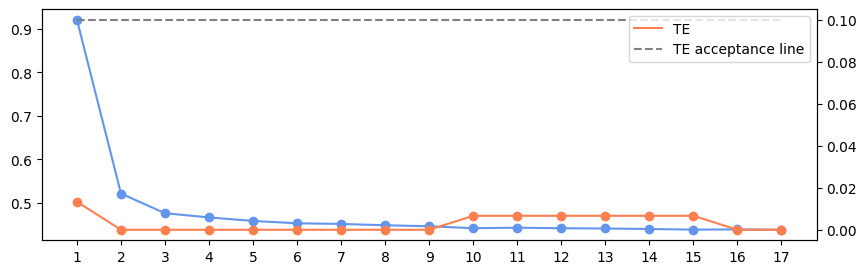

[0.921 0.522 0.477 0.467 0.459 0.453 0.452 0.449 0.447 0.442 0.443 0.442
 0.441 0.44  0.439 0.439 0.439]


In [6]:
# test convergence
from _utils.som import plot_som_convergence_over_epochs
MQEs, TEs = plot_som_convergence_over_epochs(X_scaled, epoch_min=1, epoch_max=hyparams["num_iteration"], step=1, **hyparams)
print(np.round(MQEs, 3))

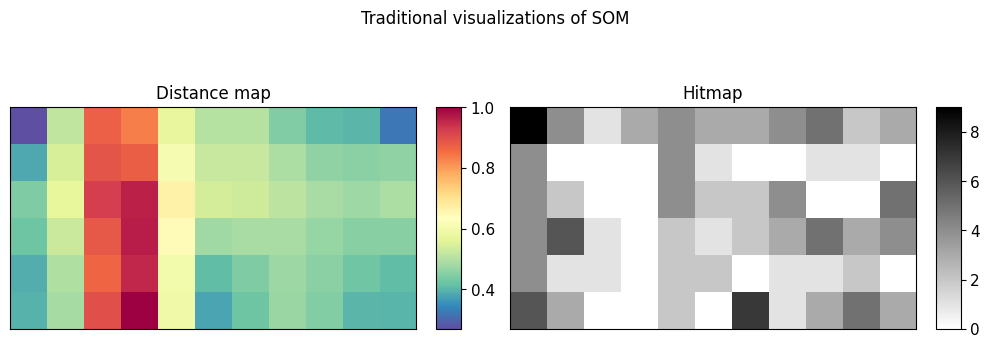

Figure saved to `_exports` folder as `00_lilypond_00.png`


In [7]:
# conventional SOM visualization
from lilypond.basin import Basin
from _utils.constants import RANDOM_SEED
basin = Basin(som, X_scaled, random_seed=RANDOM_SEED) \
	.prepare()
fig, _ = basin.legacy_pond().visualize()
export_figure(fig, EXPORTS_DIR, f"00_lilypond_00.png")

/var/folders/_8/wrnf3yvs3jg52zw_72p2w64w0000gn/T/ipykernel_27673/4242024304.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('spring_r')


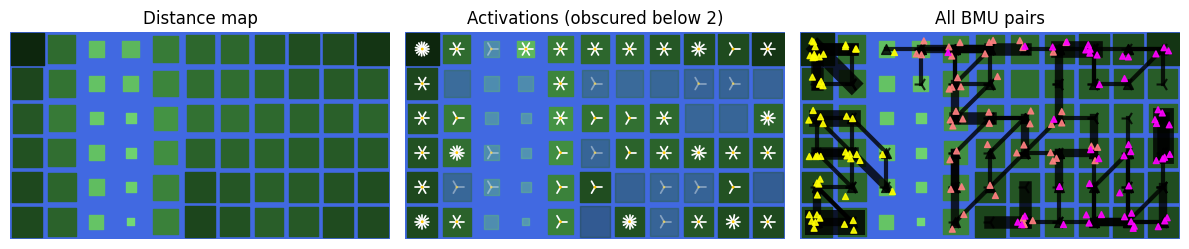

Figure saved to `_exports` folder as `00_lilypond_01.png`


In [8]:
# lilypond visualization

coloring_strategy = "distance_map"
flood_below_activations = 2

pad_style = {
    "marker": "s",
	"gap": -.055,
}

petal_style = {
	"magnifier": 3,
	"width": 1.25,
	"size_base": .4,
}

flood_style = {
	"underwater_opacity": .4,
}

figsize = (12, 3)
fig, axes = plt.subplots(1, 3, figsize=figsize)

ax = axes[0]
basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=0) \
	.style_pad(**pad_style) \
	.style_petal(hide=True) \
    .style_flood(**flood_style) \
	.observe(return_fig=True, ax=ax, title="Distance map")

ax = axes[1]
basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=flood_below_activations) \
	.discretize_petals(n_bins=5) \
	.style_pad(**pad_style) \
	.style_petal(**petal_style) \
    .style_flood(**flood_style) \
	.observe(return_fig=True, ax=ax, title=f"Activations (obscured below {flood_below_activations})")

rhizome_style = {
    "zorder": 11,
	"marker_start": "^",
	"marker_end": "3",
	"opacity": .8,
	"linewidth": 3,
}

from matplotlib.colors import ListedColormap
num_unique_y = len(np.unique(y_encoded))
cmap = plt.cm.get_cmap('spring_r')
colors = cmap(np.linspace(0, 1, num_unique_y))
cmap = ListedColormap(colors)

attract_style = {
    "cmap": cmap,
    "cmap_values": y_encoded,
    "cmap_label": "Class",
    "label": "Iris",
    "zorder": 21,
    "marker": "^",
    "size_base": 18,
    "opacity": .9,
    "subsample_ratio": None,
}

ax = axes[2]
basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=0) \
	.style_pad(**pad_style) \
	.style_petal(hide=True) \
	.style_flood(**flood_style) \
	.style_rhizome(**rhizome_style) \
	.see_rhizome(mode="all", ax=ax) \
	.attract(X_scaled, **attract_style) \
	.observe(return_fig=True, ax=ax, title="All BMU pairs")

for ax in axes:
	ax.set_aspect('equal')
	ax.axis("off")

all_axes = fig.get_axes()
colorbar_axis = all_axes[-1]
colorbar_axis.remove()

# plt.suptitle("Enhanced visualization of the SOM representation using $Lilypond$")
plt.tight_layout()
plt.show()

# export fig
export_figure(fig, EXPORTS_DIR, "00_lilypond_01.png", hide_titles=True)